In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings

# To suppress some warnings from seaborn regarding a deprecated use of palette
warnings.filterwarnings("ignore", category=FutureWarning)

rides = pd.read_csv('data/rides.csv')

rides['ride_start'] = pd.to_datetime(rides['ride_start'])
rides['date'] = rides['ride_start'].dt.date
rides['hour'] = rides['ride_start'].dt.hour
rides['day_of_week'] = rides['ride_start'].dt.day_name()

daily_hourly_tips = rides.groupby(['date', 'hour'])['tip'].sum().reset_index(name='tip_total')
avg_tip_by_hour = daily_hourly_tips.groupby('hour')['tip_total'].mean().reset_index(name='avg_tip_total')

# Function to map an hour (0-23) to the desired label.
def hour_to_label(hour):
    if hour == 0:
        return "12:00 - 12:59 AM"
    elif hour < 12:
        return f"{hour}:00 - {hour}:59 AM"
    elif hour == 12:
        return "12:00 - 12:59 PM"
    else:
        return f"{hour-12}:00 - {hour-12}:59 PM"

## Query 1: Which hour of the day led to the highest average total tip per hour?

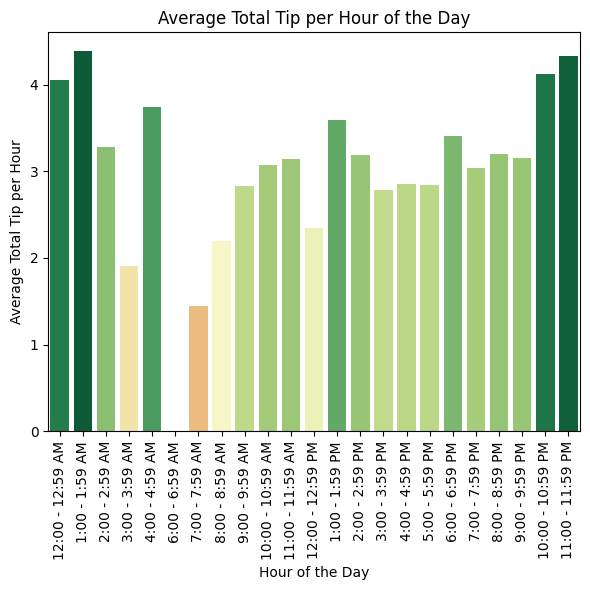

Query 1: Hour with the highest average total tip per hour:
hour             1.000000
avg_tip_total    4.383514
Name: 1, dtype: float64


In [2]:
# Apply the label mapping and sort by hour.
avg_tip_by_hour['hour_label'] = avg_tip_by_hour['hour'].apply(hour_to_label)
avg_tip_by_hour = avg_tip_by_hour.sort_values('hour')

# Create a color mapping using matplotlib's colormap such that:
# Lower average tip values map to red and higher values map to green.
norm = mpl.colors.Normalize(vmin=avg_tip_by_hour['avg_tip_total'].min(), 
                            vmax=avg_tip_by_hour['avg_tip_total'].max())
cmap = mpl.cm.RdYlGn  # RdYlGn runs from red to yellow to green.
colors = [mpl.colors.to_hex(cmap(norm(val))) for val in avg_tip_by_hour['avg_tip_total']]

# Create the bar plot.
plt.figure(figsize=(6,6))
sns.barplot(data=avg_tip_by_hour, x='hour_label', y='avg_tip_total', hue='hour_label', palette=colors, dodge=False)
plt.xlabel('Hour of the Day')
plt.ylabel('Average Total Tip per Hour')
plt.title('Average Total Tip per Hour of the Day')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('avg_tip_by_hour.jpg')
plt.show()

# Query 1: Which hour of the day led to the highest average total tip per hour?
# First sum the tips for each date and hour
daily_hourly_tips = rides.groupby(['date', 'hour'])['tip'].sum().reset_index(name='tip_total')
# Then, average these totals by hour across all days
avg_tip_by_hour = daily_hourly_tips.groupby('hour')['tip_total'].mean().reset_index(name='avg_tip_total')
best_hour = avg_tip_by_hour.loc[avg_tip_by_hour['avg_tip_total'].idxmax()]
print("Query 1: Hour with the highest average total tip per hour:")
print(best_hour)

## Query 2: On what day of the week did I have maximal average total tip per hour?

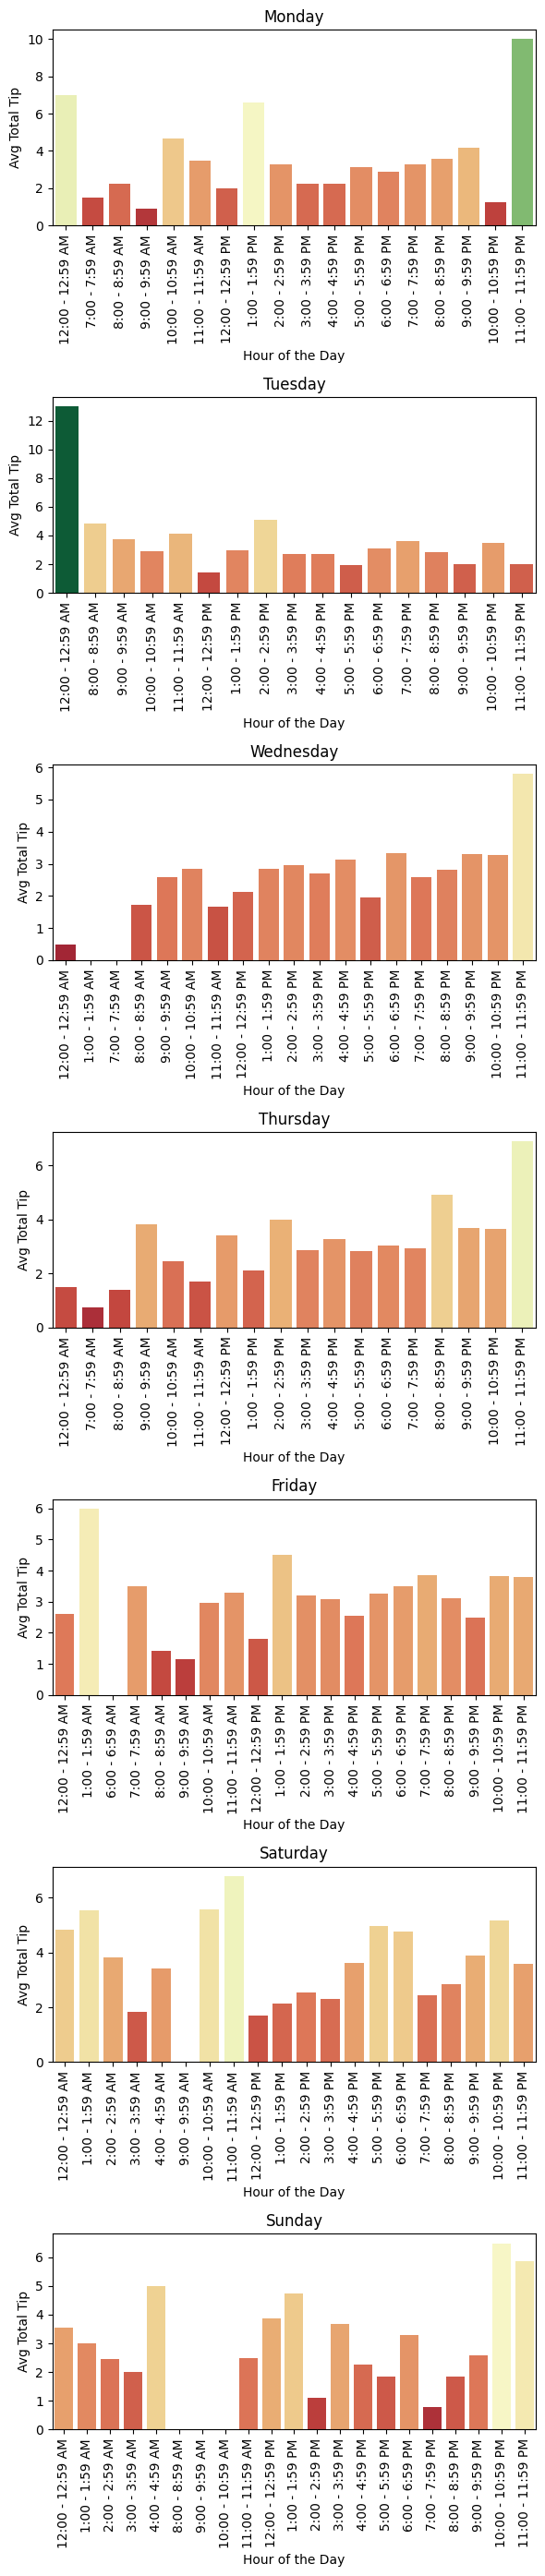


Query 2: Day of the week with the highest average total tip per hour:
day_of_week      Saturday
avg_tip_total    3.758764
Name: 2, dtype: object


In [3]:
daily_dow_hourly = rides.groupby(['date', 'day_of_week', 'hour'])['tip'].sum().reset_index(name='tip_total')
# Compute the average tip per hour for each day of the week.
avg_tip_by_dow_hour = daily_dow_hourly.groupby(['day_of_week', 'hour'])['tip_total'].mean().reset_index(name='avg_tip_total')

avg_tip_by_dow_hour['hour_label'] = avg_tip_by_dow_hour['hour'].apply(hour_to_label)

# Define the desired order for days of the week.
order_dow = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Create a 7x1 grid of subplots.
fig, axes = plt.subplots(nrows=7, ncols=1, figsize=(6, 28))

# For consistent color mapping across all subplots, compute the overall min and max avg_tip_total.
overall_min = avg_tip_by_dow_hour['avg_tip_total'].min()
overall_max = avg_tip_by_dow_hour['avg_tip_total'].max()
norm = mpl.colors.Normalize(vmin=overall_min, vmax=overall_max)
cmap = mpl.cm.RdYlGn  # Red-to-green colormap

for ax, day in zip(axes, order_dow):
    # Subset the data for this day, and sort by hour for correct ordering.
    df_day = avg_tip_by_dow_hour[avg_tip_by_dow_hour['day_of_week'] == day].sort_values('hour')
    # Create a list of colors mapping avg_tip_total for this day to the colormap.
    colors = [mpl.colors.to_hex(cmap(norm(val))) for val in df_day['avg_tip_total']]
    
    sns.barplot(data=df_day, x='hour_label', y='avg_tip_total', hue='hour_label', palette=colors, ax=ax)
    ax.set_title(day)
    ax.set_xlabel('Hour of the Day')
    ax.set_ylabel('Avg Total Tip')
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig('avg_tip_by_day_7x1.jpg')
plt.show()

# Query 2: On what day of the week did I have maximal average total tip per hour?
# Using the day_of_week column, group by date, day_of_week, and hour to compute the hourly tip total
daily_dow_hourly_tips = rides.groupby(['date', 'day_of_week', 'hour'])['tip'].sum().reset_index(name='tip_total')
# Now, for each day of the week, average the hourly totals across all dates with that day
avg_tip_by_dow = daily_dow_hourly_tips.groupby('day_of_week')['tip_total'].mean().reset_index(name='avg_tip_total')
best_day = avg_tip_by_dow.loc[avg_tip_by_dow['avg_tip_total'].idxmax()]
print("\nQuery 2: Day of the week with the highest average total tip per hour:")
print(best_day)

## Query 3: Which ride_type leads to the highest average total tip per hour?

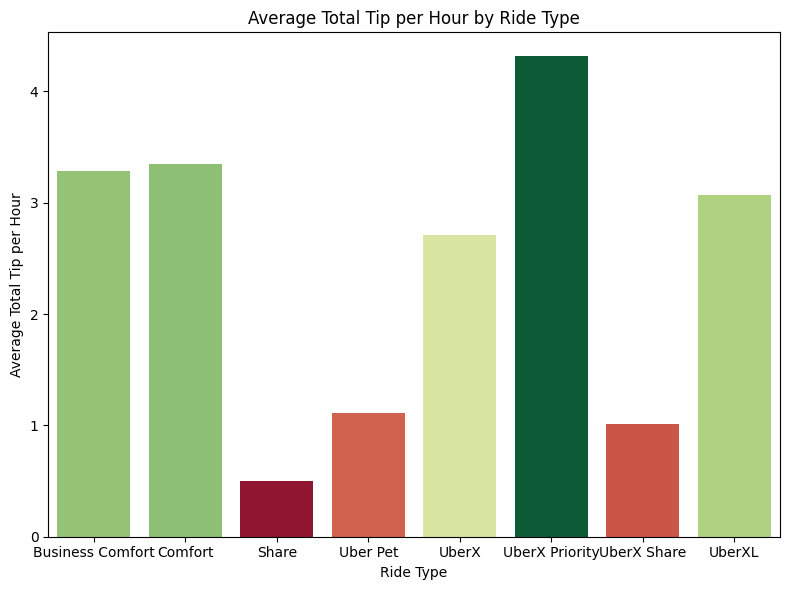


Query 3: Ride type with the highest average total tip per hour:
ride_type        UberX Priority
avg_tip_total          4.314286
Name: 5, dtype: object


In [4]:
# Query 3: Which ride_type leads to the highest average total tip per hour?
# Group by date, ride_type, and hour to compute total tip per hour for each ride.
daily_ride_hourly_tips = rides.groupby(['date', 'ride_type', 'hour'])['tip'].sum().reset_index(name='tip_total')
# Then, average these hourly tip totals for each ride_type over the entire dataset.
avg_tip_by_ride_type = daily_ride_hourly_tips.groupby('ride_type')['tip_total'].mean().reset_index(name='avg_tip_total')

# Create a color mapping using the RdYlGn colormap
norm = mpl.colors.Normalize(vmin=avg_tip_by_ride_type['avg_tip_total'].min(), 
                            vmax=avg_tip_by_ride_type['avg_tip_total'].max())
cmap = mpl.cm.RdYlGn  # Red-to-green colormap
colors = [mpl.colors.to_hex(cmap(norm(val))) for val in avg_tip_by_ride_type['avg_tip_total']]

plt.figure(figsize=(8,6))
sns.barplot(data=avg_tip_by_ride_type, x='ride_type', y='avg_tip_total', hue='ride_type', palette=colors)
plt.xlabel('Ride Type')
plt.ylabel('Average Total Tip per Hour')
plt.title('Average Total Tip per Hour by Ride Type')
plt.tight_layout()
plt.savefig('avg_tip_by_ride_type.jpg')
plt.show()

# Similarly, group by date, ride_type, and hour, then average the tip totals for each ride_type
daily_ride_hourly_tips = rides.groupby(['date', 'ride_type', 'hour'])['tip'].sum().reset_index(name='tip_total')
avg_tip_by_ride_type = daily_ride_hourly_tips.groupby('ride_type')['tip_total'].mean().reset_index(name='avg_tip_total')
best_ride_type = avg_tip_by_ride_type.loc[avg_tip_by_ride_type['avg_tip_total'].idxmax()]
print("\nQuery 3: Ride type with the highest average total tip per hour:")
print(best_ride_type)

## Query 4: Which five zip codes lead to the highest average total tip per hour?

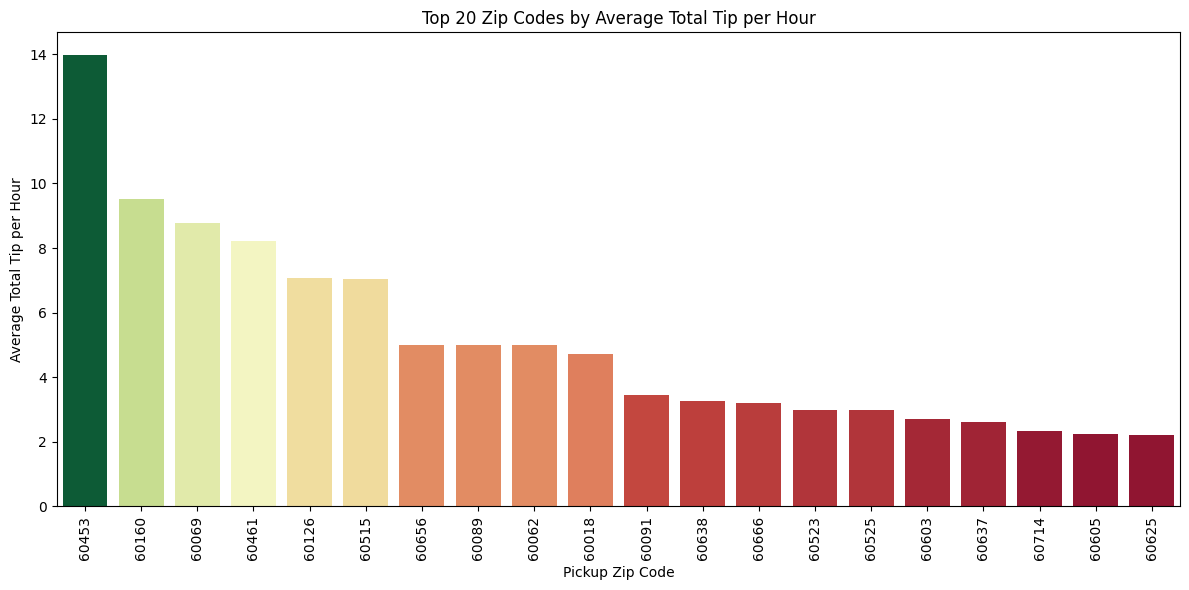


Query 4: Top 5 zip codes with highest average total tip per hour:
    pickup_zip  avg_tip_total
42       60453      13.980000
28       60160       9.526667
10       60069       8.790000
44       60461       8.230000
23       60126       7.075000


In [5]:
# Group the data by date, pickup_zip, and hour to compute the total tip per hour.
daily_zip_hourly = rides.groupby(['date', 'pickup_zip', 'hour'])['tip'].sum().reset_index(name='tip_total')

# Compute the average total tip per hour across all days for each pickup_zip.
avg_tip_by_zip = daily_zip_hourly.groupby('pickup_zip')['tip_total'].mean().reset_index(name='avg_tip_total')

# Sort the data in descending order by avg_tip_total, then select the top 20 zip codes.
top20_zip = avg_tip_by_zip.sort_values('avg_tip_total', ascending=False).head(20)

# Specify the order for the x-axis (sorted by avg_tip_total descending).
order = top20_zip['pickup_zip'].tolist()

# Create a color mapping using the RdYlGn colormap: lower tip values map to red; higher values map to green.
norm = mpl.colors.Normalize(vmin=top20_zip['avg_tip_total'].min(), vmax=top20_zip['avg_tip_total'].max())
cmap = mpl.cm.RdYlGn  # Red-to-green colormap
colors = [mpl.colors.to_hex(cmap(norm(val))) for val in top20_zip['avg_tip_total']]

# Create the bar chart, specifying the x-axis order explicitly.
plt.figure(figsize=(12,6))
sns.barplot(data=top20_zip, x='pickup_zip', y='avg_tip_total', palette=colors, order=order, legend=False)
plt.xlabel('Pickup Zip Code')
plt.ylabel('Average Total Tip per Hour')
plt.title('Top 20 Zip Codes by Average Total Tip per Hour')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('avg_tip_by_top20_zip.jpg')
plt.show()

# Query 4: Which five zip codes lead to the highest average total tip per hour?
# We group by date, pickup_zip, and hour, then average the totals for each zip code
daily_zip_hourly_tips = rides.groupby(['date', 'pickup_zip', 'hour'])['tip'].sum().reset_index(name='tip_total')
avg_tip_by_zip = daily_zip_hourly_tips.groupby('pickup_zip')['tip_total'].mean().reset_index(name='avg_tip_total')
top5_zips = avg_tip_by_zip.sort_values(by='avg_tip_total', ascending=False).head(5)
print("\nQuery 4: Top 5 zip codes with highest average total tip per hour:")
print(top5_zips)